In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Cargamos los datos procesados que guardamos en el paso anterior
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# 2. Entrenamos un modelo de Random Forest (Bosque Aleatorio)
# class_weight='balanced' le enseña al modelo a prestarle atención al 16% de clientes en Churn
modelo = RandomForestClassifier(random_state=42, class_weight='balanced')
modelo.fit(X_train, y_train)

# 3. Predecimos en el grupo de examen (Test)
y_pred = modelo.predict(X_test)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


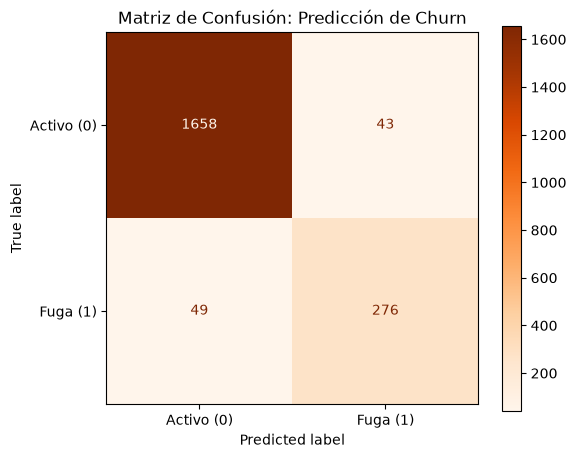

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

  Activo (0)       0.97      0.97      0.97      1701
    Fuga (1)       0.87      0.85      0.86       325

    accuracy                           0.95      2026
   macro avg       0.92      0.91      0.92      2026
weighted avg       0.95      0.95      0.95      2026



In [2]:
# 1. Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Activo (0)', 'Fuga (1)'], 
    cmap='Oranges', 
    ax=ax
)
plt.title('Matriz de Confusión: Predicción de Churn', fontsize=12)
plt.grid(False)
plt.show()

# 2. Reporte de Métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=['Activo (0)', 'Fuga (1)']))

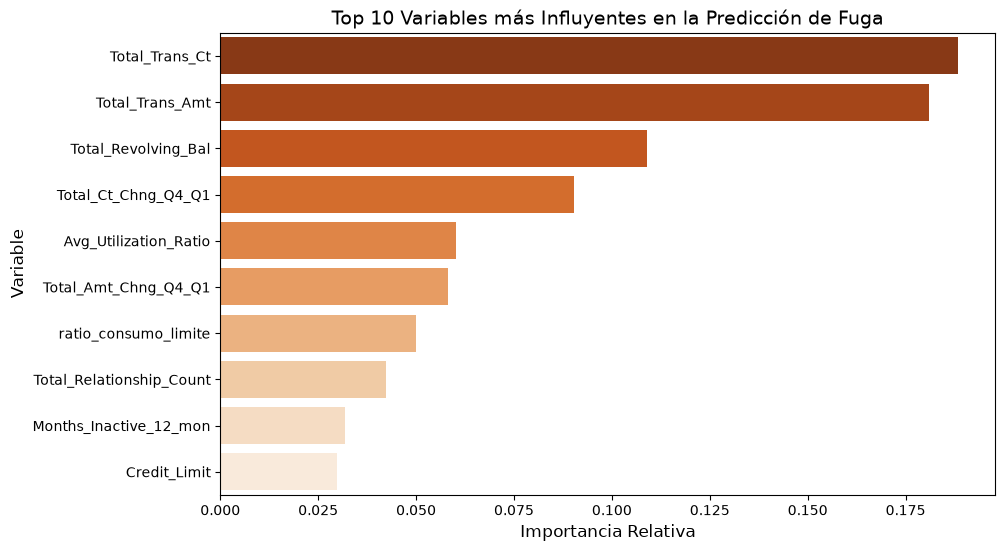

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener la importancia de cada variable desde el modelo
importancias = modelo.feature_importances_
columnas = X_train.columns

# 2. Crear un DataFrame y ordenar las top 10 más importantes
df_imp = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10)

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_imp, 
    x='Importancia', 
    y='Variable', 
    hue='Variable', 
    palette='Oranges_r', 
    legend=False
)
plt.title('Top 10 Variables más Influyentes en la Predicción de Fuga', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.show()

In [4]:
# Unimos la predicción del modelo al dataset de prueba para llevarlo al Dashboard
df_dashboard = X_test.copy()
df_dashboard['Churn_Real'] = y_test
df_dashboard['Churn_Predicho'] = y_pred

# Exportamos a la carpeta dashboard/
df_dashboard.to_csv('../dashboard/datos_dashboard.csv', index=False)
print("¡Dataset para el Dashboard exportado con éxito a dashboard/datos_dashboard.csv!")

¡Dataset para el Dashboard exportado con éxito a dashboard/datos_dashboard.csv!
